In [14]:
import torch
import torch.nn as nn
from torch.profiler import profile, record_function, ProfilerActivity
from numba import cuda
import numpy as np
import math

In [15]:
class TransformerBase(nn.Module):
    def __init__(self, vocab_size=1000, d_model=512, n_heads=4, d_ff=512 * 4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.n_heads = n_heads
        self.q_proj = nn.Linear(d_model, d_model, bias=False)
        self.k_proj = nn.Linear(d_model, d_model, bias=False)
        self.v_proj = nn.Linear(d_model, d_model, bias=False)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        raise NotImplementedError()

In [16]:
class CpuPipeline(TransformerBase):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    def forward(self, x):
        # x: [N]
        # ['heelo', 'im' , 'a', 'dog']
        with record_function("1_embedding"):
            x = self.embedding(x) # [N, D]

        B, N, D = x.shape

        q = self.q_proj(x)  #  [x(N, D) . Wq(D, k)] -> [N, k]
        k = self.k_proj(x)  # [N, k] -> kT []
        v = self.v_proj(x)  # [N, k]

        with record_function("2_attention_total"):

            with record_function("2a_qk_matmul"):
                attn_scores = torch.matmul(q, k.transpose(-2, -1)) / D ** 0.5

            # x: N N

            with record_function("2b_softmax"):
                attn_weights = torch.softmax(attn_scores, dim=-1)

            with record_function("2c_value_weighted_sum"):
                attn_out = torch.matmul(attn_weights, v)

        x = self.norm1(x + attn_out)

        with record_function("3_ffn"):
            ffn_out = self.ffn(x)
            x = self.norm2(x + ffn_out)

        return x

In [17]:
@cuda.jit
def _matmul(A, B, C):
    i, j = cuda.grid(2)
    if i < C.shape[0] and j < C.shape[1]:
        tmp = 0.
        for k in range(A.shape[1]):
            tmp += A[i, k] * B[k, j]
        C[i, j] = tmp

In [18]:
@cuda.jit
def _softmax(input, out):
    j = cuda.grid(1)
    if j < input.shape[1]:
        tmp = 0.
        for i in range(input.shape[0]):
            tmp += math.exp(input[i, j])
        for i in range(input.shape[0]):
            out[i, j] = math.exp(input[i, j]) / tmp

In [19]:
class GpuV1(TransformerBase):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    def forward(self, x):
        # x: [N]
        # ['heelo', 'im' , 'a', 'dog']
        with record_function("1_embedding"):
            x = self.embedding(x) # [N, D]

        B, N, D = x.shape

        q = self.q_proj(x).squeeze(0).cuda()  # [x(N, D) . Wq(D, N)] -> [N, N]
        k = self.k_proj(x).squeeze(0).cuda()  # [N, N] -> kT []
        v = self.v_proj(x).squeeze(0).cuda()  # [N, N]

        attn_scores = torch.empty((N, N), device=torch.device('cuda'))
        attn_weights = torch.empty((N, N), device=torch.device('cuda'))
        attn_out = torch.empty((N, N), device=torch.device('cuda'))
        with record_function("2_attention_total"):
            with record_function("2a_qk_matmul"):
                kT = k.transpose(-2, -1)
                threadsperblock = (16, 16)
                blockspergrid_x = int(np.ceil(q.shape[0] / threadsperblock[0]))
                blockspergrid_y = int(np.ceil(kT.shape[1] / threadsperblock[1]))
                blockspergrid = (blockspergrid_x, blockspergrid_y)

                _matmul[blockspergrid, threadsperblock](q, kT, attn_scores)
                # x [N N]

                attn_scores = attn_scores / D ** 0.5

            with record_function("2b_softmax"):
                tpb = 256
                bpg = int(np.ceil(attn_scores.shape[1] / tpb))
                _softmax[bpg, tpb](attn_scores, attn_weights)

            with record_function("2c_value_weighted_sum"):
                tpb = (16, 16)
                bpg_x = int(np.ceil(attn_weights.shape[0] / tpb[0]))
                bpg_y = int(np.ceil(v.shape[1] / tpb[1]))
                _matmul[(bpg_x, bpg_y), tpb](attn_weights, v, attn_out)

        attn_out = attn_out.to(torch.device('cpu'))
        x = self.norm1(x + attn_out)

        with record_function("3_ffn"):
            ffn_out = self.ffn(x)
            x = self.norm2(x + ffn_out)

        return x


In [20]:
class GpuV2(TransformerBase):
    pass

In [21]:
class GpuV3(TransformerBase):
    pass

In [22]:
N = 2 ** 15
B = 1
inputs = torch.randint(0, 1000, (B, N)) # [B, N]

In [23]:
# model = CpuPipeline(d_model=N).eval()
# with profile(
#     activities=[ProfilerActivity.CPU],
#     record_shapes=True,
#     profile_memory=True
# ) as prof:
#     with torch.no_grad():
#         with record_function("total_inference_pipeline"):
#             _ = model(inputs)
# print(prof.key_averages().table(sort_by="cpu_time_total"))


In [24]:
# model = GpuV1(d_model=N).eval()
# with profile(
#     activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
#     record_shapes=True,
#     profile_memory=True
# ) as prof:
#     with torch.no_grad():
#         with record_function("total_inference_pipeline"):
#             _ = model(inputs)
# print(prof.key_averages().table(sort_by="cpu_time_total"))

USDT:2026-07-07 03:47:38 14390:14390 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-07 03:47:38 14390:14390 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-07-07 03:47:38 14390:14390 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-07 03:47:38 14390:14390 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-07-07 03:47:38 14390:14390 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-07 03:47:38 14390:14390 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-07-07 03:47:38 14390:14390 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-07 03:47:38 14390:14390 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-07-07 03:47:38 14390:14390 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-07 03:47:38 14390:14390 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-07-07 03:47:38 14390:14390 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-07 03:47:39 14390:14390 

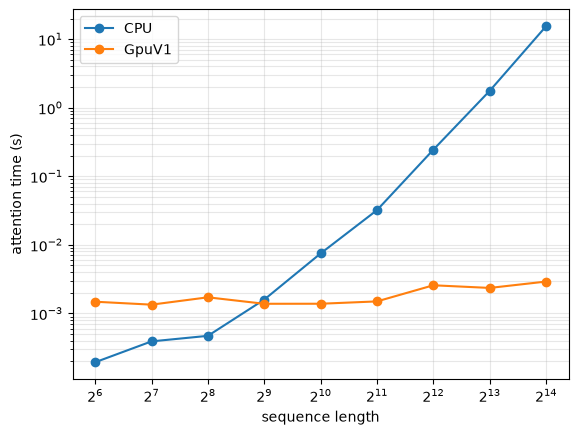

In [28]:
import matplotlib.pyplot as plt

start, end = 6, 15
seq_lens = [2 ** x for x in range(start, end)]
def plot_cpu_vs_gpu(seq_lens=seq_lens, repeats=3):
    # ponytail: d_model=n because GpuV1 assumes D == N (attn_out is [N, N])
    def bench_attention(cls, n):
        model = cls(d_model=n).eval()
        x = torch.randint(0, 1000, (1, n))
        with torch.no_grad():
            model(x)  # warmup (numba JIT on first GpuV1 call)
            with profile(activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA]) as prof:
                for _ in range(repeats):
                    model(x)
                torch.cuda.synchronize()
        evt = next(e for e in prof.key_averages() if e.key == "2_attention_total")
        # ponytail: device_time for GPU kernels (async, invisible to cpu_time), cpu_time otherwise
        return max(evt.cpu_time_total, evt.device_time_total) / repeats / 1e6  # us -> s

    cpu_t = [bench_attention(CpuPipeline, n) for n in seq_lens]
    gpu_t = [bench_attention(GpuV1, n) for n in seq_lens]

    plt.plot(seq_lens, cpu_t, marker='o', label='CPU')
    plt.plot(seq_lens, gpu_t, marker='o', label='GpuV1')
    plt.xscale('log', base=2); plt.yscale('log')
    plt.xlabel('sequence length'); plt.ylabel('attention time (s)')
    plt.legend(); plt.grid(True, which='both', alpha=0.3)
    plt.show()

plot_cpu_vs_gpu()

In [ ]:
# attention % of CPU pipeline
model = CpuPipeline(d_model=N).eval()
with torch.no_grad():
    with profile(activities=[ProfilerActivity.CPU]) as prof:
        with record_function("total_inference_pipeline"):
            _ = model(inputs)
ka = {e.key: e for e in prof.key_averages()}
attn = ka["2_attention_total"].cpu_time_total
total = ka["total_inference_pipeline"].cpu_time_total
print(f"CPU: attention = {attn / total:.1%} of pipeline ({attn / 1e3:.1f} ms / {total / 1e3:.1f} ms)")

In [ ]:
# attention % of GpuV1 pipeline
model = GpuV1(d_model=N).eval()
with torch.no_grad():
    model(inputs)  # warmup (numba JIT)
    with profile(activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA]) as prof:
        with record_function("total_inference_pipeline"):
            _ = model(inputs)
        torch.cuda.synchronize()
ka = {e.key: e for e in prof.key_averages()}
# ponytail: attention kernels are async -> take device time; total cpu_time is real (the .to('cpu') syncs)
attn = max(ka["2_attention_total"].cpu_time_total, ka["2_attention_total"].device_time_total)
total = ka["total_inference_pipeline"].cpu_time_total
print(f"GpuV1: attention = {attn / total:.1%} of pipeline ({attn / 1e3:.1f} ms / {total / 1e3:.1f} ms)")